In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("ecommerce_sales_data.csv")

In [3]:
df.head()

,Order ID,Order Date,Ship Date,Country,Segment,Product,Sales,Profit,Discount,Quantity
0,1001,2022-01-01,2022-01-03,Canada,Corporate,Accessories,2643.26,1148.94,0.22,9
1,1002,2022-01-02,2022-01-04,Australia,Corporate,Laptop,3419.96,-207.13,0.42,3
2,1003,2022-01-03,2022-01-05,UK,Corporate,Accessories,1628.13,1165.86,0.13,7
3,1004,2022-01-04,2022-01-06,Australia,Home Office,Accessories,3892.56,580.59,0.21,8
4,1005,2022-01-05,2022-01-07,Australia,Consumer,Phone,3887.32,1189.33,0.02,2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Order ID    1200 non-null   int64  
 1   Order Date  1200 non-null   object 
 2   Ship Date   1200 non-null   object 
 3   Country     1200 non-null   object 
 4   Segment     1200 non-null   object 
 5   Product     1200 non-null   object 
 6   Sales       1200 non-null   float64
 7   Profit      1200 non-null   float64
 8   Discount    1200 non-null   float64
 9   Quantity    1200 non-null   int64  
dtypes: float64(3), int64(2), object(5)
memory usage: 93.9+ KB


In [5]:
df.describe()

,Order ID,Sales,Profit,Discount,Quantity
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,1600.500000,2543.688050,480.164017,0.248883,5.020000
std,346.554469,1412.819487,574.906035,0.145210,2.678104
min,1001.000000,100.060000,-499.940000,0.000000,1.000000
25%,1300.750000,1316.040000,-20.737500,0.120000,3.000000
50%,1600.500000,2551.155000,471.195000,0.250000,5.000000
75%,1900.250000,3776.917500,971.102500,0.380000,7.000000
max,2200.000000,4997.830000,1495.500000,0.500000,9.000000


In [6]:
df.shape

(1200, 10)

In [7]:
df.isnull().sum()

Order ID      0
Order Date    0
Ship Date     0
Country       0
Segment       0
Product       0
Sales         0
Profit        0
Discount      0
Quantity      0
dtype: int64

In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

In [9]:
df.isnull().sum()

Order ID      0
Order Date    0
Ship Date     0
Country       0
Segment       0
Product       0
Sales         0
Profit        0
Discount      0
Quantity      0
dtype: int64

In [10]:
df.duplicated().sum()
df = df.drop_duplicates()

In [11]:
df.dtypes

Order ID               int64
Order Date    datetime64[ns]
Ship Date     datetime64[ns]
Country               object
Segment               object
Product               object
Sales                float64
Profit               float64
Discount             float64
Quantity               int64
dtype: object

In [12]:
df['Quantity'] = df['Quantity'].astype(int)

In [13]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order ID    1200 non-null   int64         
 1   Order Date  1200 non-null   datetime64[ns]
 2   Ship Date   1200 non-null   datetime64[ns]
 3   Country     1200 non-null   object        
 4   Segment     1200 non-null   object        
 5   Product     1200 non-null   object        
 6   Sales       1200 non-null   float64       
 7   Profit      1200 non-null   float64       
 8   Discount    1200 non-null   float64       
 9   Quantity    1200 non-null   int64         
 10  Year        1200 non-null   int32         
 11  Month       1200 non-null   int32         
 12  Day         1200 non-null   int32         
dtypes: datetime64[ns](2), float64(3), int32(3), int64(2), object(3)
memory usage: 107.9+ KB


In [15]:
df.describe()

,Order ID,Order Date,Ship Date,Sales,Profit,Discount,Quantity,Year,Month,Day
count,1200.000000,1200,1200,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,1600.500000,2023-08-23 12:00:00,2023-08-25 12:00:00,2543.688050,480.164017,0.248883,5.020000,2023.174167,6.153333,15.621667
min,1001.000000,2022-01-01 00:00:00,2022-01-03 00:00:00,100.060000,-499.940000,0.000000,1.000000,2022.000000,1.000000,1.000000
25%,1300.750000,2022-10-27 18:00:00,2022-10-29 18:00:00,1316.040000,-20.737500,0.120000,3.000000,2022.000000,3.000000,8.000000
50%,1600.500000,2023-08-23 12:00:00,2023-08-25 12:00:00,2551.155000,471.195000,0.250000,5.000000,2023.000000,6.000000,16.000000
75%,1900.250000,2024-06-18 06:00:00,2024-06-20 06:00:00,3776.917500,971.102500,0.380000,7.000000,2024.000000,9.000000,23.000000
max,2200.000000,2025-04-14 00:00:00,2025-04-16 00:00:00,4997.830000,1495.500000,0.500000,9.000000,2025.000000,12.000000,31.000000
std,346.554469,NaN,NaN,1412.819487,574.906035,0.145210,2.678104,0.962430,3.521149,8.802164


In [16]:
df.head()

,Order ID,Order Date,Ship Date,Country,Segment,Product,Sales,Profit,Discount,Quantity,Year,Month,Day
0,1001,2022-01-01,2022-01-03,Canada,Corporate,Accessories,2643.26,1148.94,0.22,9,2022,1,1
1,1002,2022-01-02,2022-01-04,Australia,Corporate,Laptop,3419.96,-207.13,0.42,3,2022,1,2
2,1003,2022-01-03,2022-01-05,UK,Corporate,Accessories,1628.13,1165.86,0.13,7,2022,1,3
3,1004,2022-01-04,2022-01-06,Australia,Home Office,Accessories,3892.56,580.59,0.21,8,2022,1,4
4,1005,2022-01-05,2022-01-07,Australia,Consumer,Phone,3887.32,1189.33,0.02,2,2022,1,5


In [17]:
df.to_csv("E-Commerce_sales_data.csv", index=False)

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("E-Commerce_sales_data.csv")
df.head()

,Order ID,Order Date,Ship Date,Country,Segment,Product,Sales,Profit,Discount,Quantity,Year,Month,Day
0,1001,2022-01-01,2022-01-03,Canada,Corporate,Accessories,2643.26,1148.94,0.22,9,2022,1,1
1,1002,2022-01-02,2022-01-04,Australia,Corporate,Laptop,3419.96,-207.13,0.42,3,2022,1,2
2,1003,2022-01-03,2022-01-05,UK,Corporate,Accessories,1628.13,1165.86,0.13,7,2022,1,3
3,1004,2022-01-04,2022-01-06,Australia,Home Office,Accessories,3892.56,580.59,0.21,8,2022,1,4
4,1005,2022-01-05,2022-01-07,Australia,Consumer,Phone,3887.32,1189.33,0.02,2,2022,1,5


In [19]:
df.shape

(1200, 13)

In [20]:
df.columns

Index(['Order ID', 'Order Date', 'Ship Date', 'Country', 'Segment', 'Product',
       'Sales', 'Profit', 'Discount', 'Quantity', 'Year', 'Month', 'Day'],
      dtype='object')

In [21]:
df.describe()

,Order ID,Sales,Profit,Discount,Quantity,Year,Month,Day
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,1600.500000,2543.688050,480.164017,0.248883,5.020000,2023.174167,6.153333,15.621667
std,346.554469,1412.819487,574.906035,0.145210,2.678104,0.962430,3.521149,8.802164
min,1001.000000,100.060000,-499.940000,0.000000,1.000000,2022.000000,1.000000,1.000000
25%,1300.750000,1316.040000,-20.737500,0.120000,3.000000,2022.000000,3.000000,8.000000
50%,1600.500000,2551.155000,471.195000,0.250000,5.000000,2023.000000,6.000000,16.000000
75%,1900.250000,3776.917500,971.102500,0.380000,7.000000,2024.000000,9.000000,23.000000
max,2200.000000,4997.830000,1495.500000,0.500000,9.000000,2025.000000,12.000000,31.000000


In [22]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year

# 1. Monthly Sales Trend

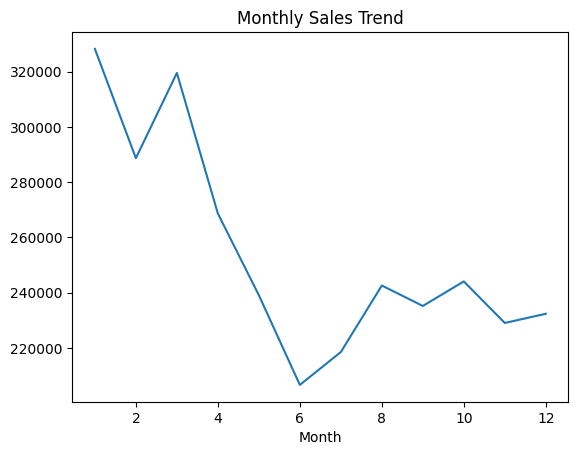

In [23]:
monthly_sales = df.groupby('Month')['Sales'].sum()
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.show()

# 2. Sales by Country

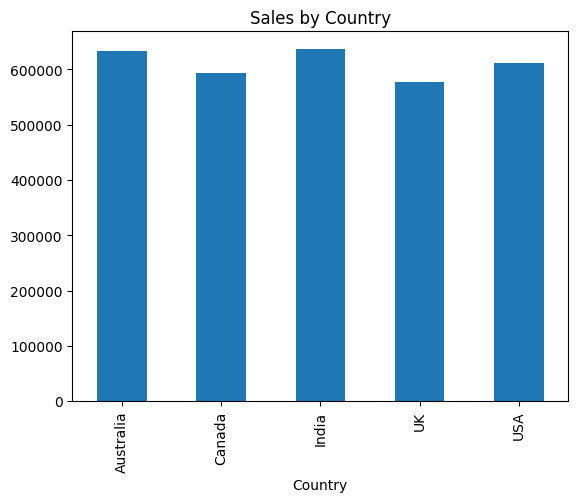

In [24]:
country_sales = df.groupby('Country')['Sales'].sum()
country_sales.plot(kind='bar')
plt.title("Sales by Country")
plt.show()

# 3. Top Selling Products

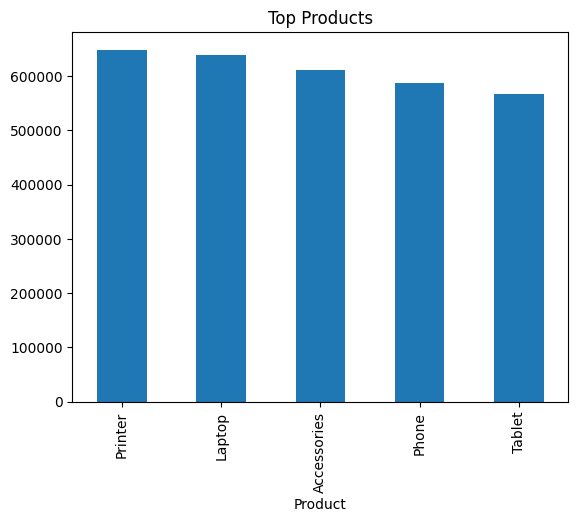

In [25]:
top_products = df.groupby('Product')['Sales'].sum().sort_values(ascending=False)

top_products.plot(kind='bar')
plt.title("Top Products")
plt.show()

# 4. Profit Analysis

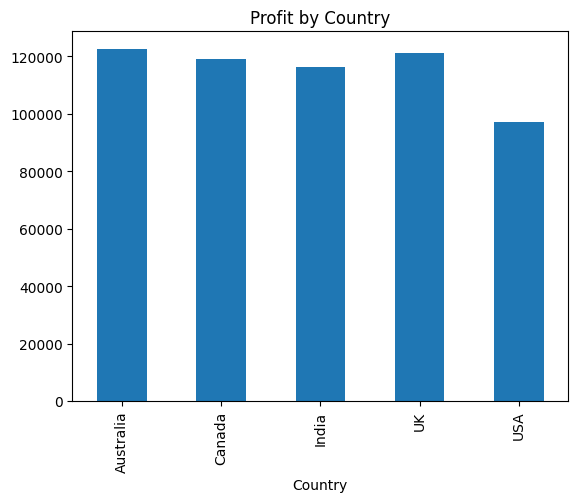

In [26]:
df.groupby('Country')['Profit'].sum().plot(kind='bar')
plt.title("Profit by Country")
plt.show()

# 5. Discount vs Profit

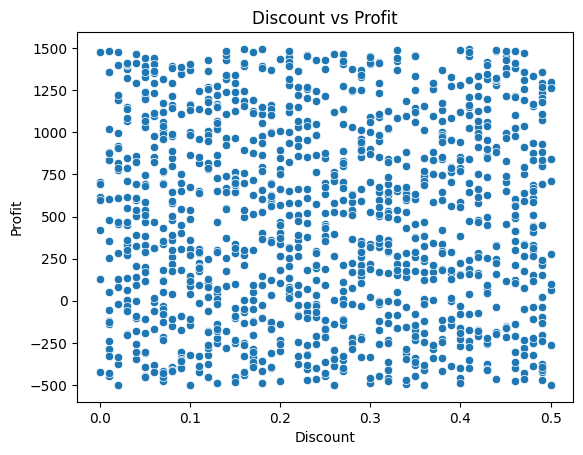

In [27]:
sns.scatterplot(x='Discount', y='Profit', data=df)
plt.title("Discount vs Profit")
plt.show()

# 6. Sales by Segment

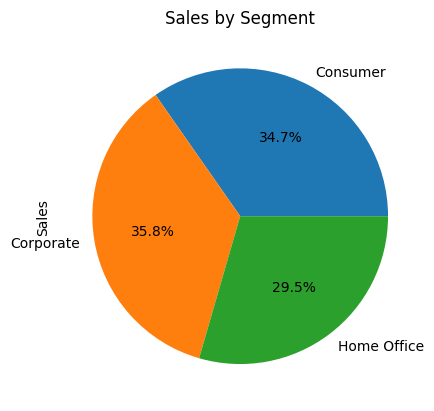

In [28]:
df.groupby('Segment')['Sales'].sum().plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales by Segment")
plt.show()

# Key Insights

1.Sales peak in specific months
2.Certain countries dominate revenue
3.High discounts reduce profit
4.Few products contribute most sales